In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

In [2]:

# 1. Load data into a Pandas DataFrame for EDA
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)


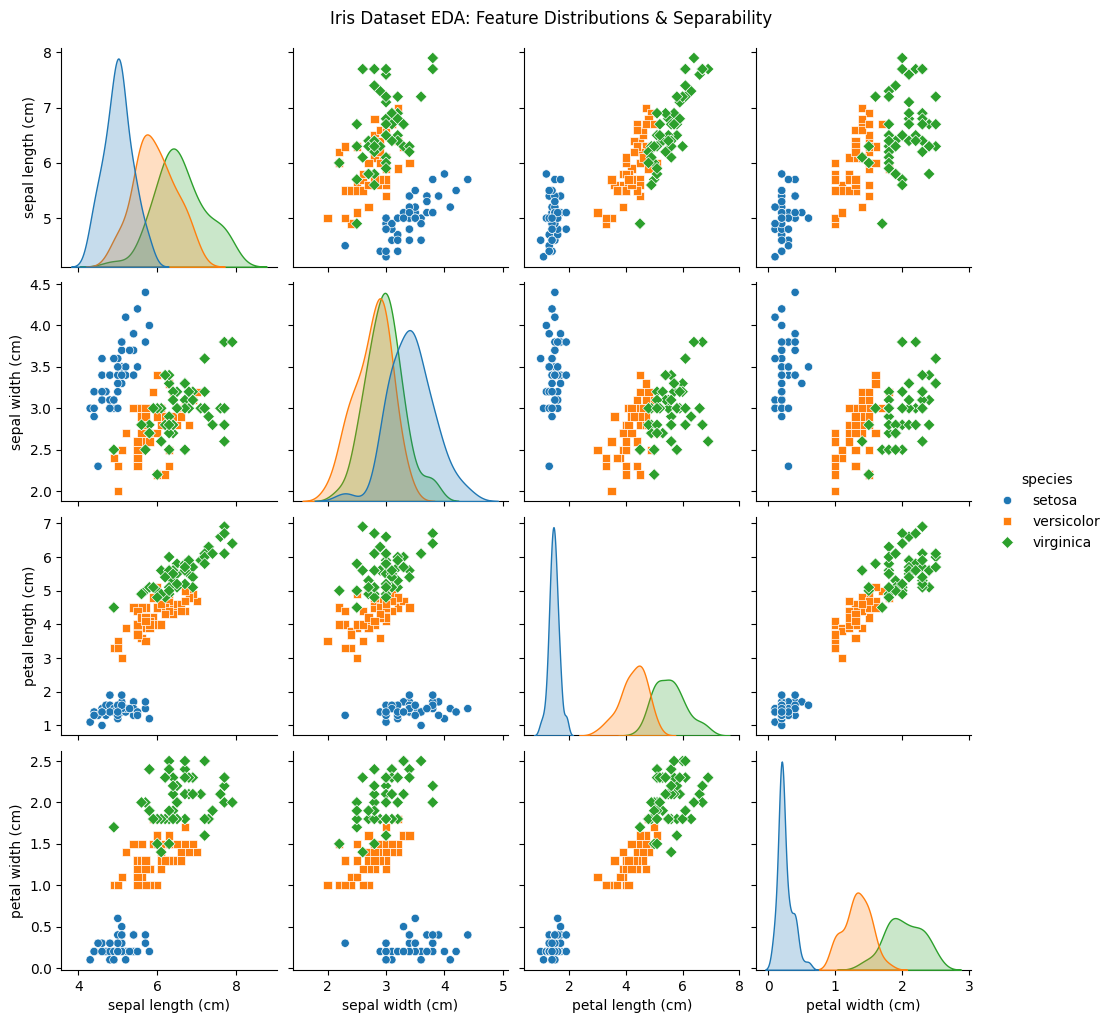

In [3]:

# 2. Generate a Pairplot to visualize distributions and separability
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("Iris Dataset EDA: Feature Distributions & Separability", y=1.02)
plt.show()

In [4]:

X, y = load_iris(return_X_y=True)
target_names = load_iris().target_names

# 2. Isolate training data from testing data (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:

lda = LinearDiscriminantAnalysis(n_components=2)

lda.fit(X_train, y_train)


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",2
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [7]:

y_pred = lda.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")



Model Accuracy: 100.00%



In [ ]:

# 5. Manual Input Inference
print("-" * 40)
print("MANUAL DATA INFERENCE")

# Input format: [sepal length, sepal width, petal length, petal width]
# Reshaping to (1, 4) because scikit-learn expects a 2D array for predictions
manual_input = np.array([5.1, 3.5, 1.4, 0.2]).reshape(1, -1)

# Predict the class and the underlying probabilities
predicted_class_index = lda.predict(manual_input)[0]
predicted_probabilities = lda.predict_proba(manual_input)[0]

print(f"Input Measurements: {manual_input[0]}")
print(f"Predicted Species: {target_names[predicted_class_index].upper()}")
print(f"Probability Scores: Setosa ({predicted_probabilities[0]:.4f}), "
      f"Versicolor ({predicted_probabilities[1]:.4f}), "
      f"Virginica ({predicted_probabilities[2]:.4f})")